## 1. Linear Regression
**Fits a linear model with coefficients to minimise the residual sum of squares** between the observed targets in the dataset. It takes in its fit method arguments X, y, sample_weight and stores the coefficients of the linear model in its coef_ and intercept_ attributes.

**The coefficient estimates for Ordinary Least Squares rely on the independence of the features.** 
* When features are correlated and some columns of the design matrix have an approximately linear dependence, the design matrix becomes close to singular and as a result, 
* the least-squares estimate becomes highly sensitive to random errors in the observed target, producing a large variance. This situation of **multicollinearity** can arise, for example, when data are collected without an experimental design.

In [1]:
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
#Create the arrays that represent the values of the x and y axis
x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

In [3]:
#Execute a method that returns some important key values of Linear Regression
slope, intercept, r, p, std_err = stats.linregress(x, y)

In [4]:
# measure the correlation 
corr, _ = stats.pearsonr(x, y)
print('Pearsons correlation: %.3f' % corr)


Pearsons correlation: -0.759


In [5]:
#Create a function that uses the slope and intercept values to return a new value. 
#This new value represents where on the y-axis the corresponding x value will be placed
def myfunc(x):
  return slope * x + intercept

In [6]:
#Run each value of the x array through the function. This will result in a new array with new values for the y-axis
mymodel = list(map(myfunc, x))

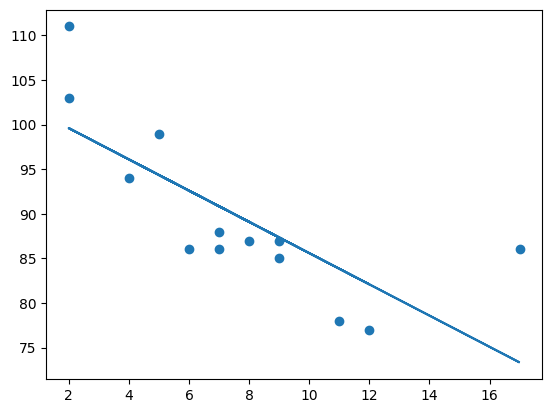

In [7]:
#Draw the original scatter plot & the line of linear regression
plt.scatter(x, y)
plt.plot(x, mymodel)
plt.show()

## Predict Future Values

In [8]:
from scipy import stats

x = [5,7,8,7,2,17,2,9,4,11,12,9,6]
y = [99,86,87,88,111,86,103,87,94,78,77,85,86]

slope, intercept, r, p, std_err = stats.linregress(x, y)

def myfunc(x):
  return intercept + slope * x 

speed = myfunc(20)

print(speed)

68.08020603384841


## Additional Exercise



In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [10]:
#load data
data = {
    'area': [ 1000, 1500, 2000, 2300, 2800, 3200, 3500, 4000, 4500, 5000, 5500, 6200, 7000, 8000, 9000

    ],
    'prices': [250000, 390000, 330000, 510000, 420000, 610000, 540000, 760000, 650000, 820000,    740000, 1050000, 920000, 1280000, 1190000
               ]
}

df = pd.DataFrame(data)
df

,area,prices
0,1000,250000
1,1500,390000
2,2000,330000
3,2300,510000
4,2800,420000
5,3200,610000
6,3500,540000
7,4000,760000
8,4500,650000
9,5000,820000


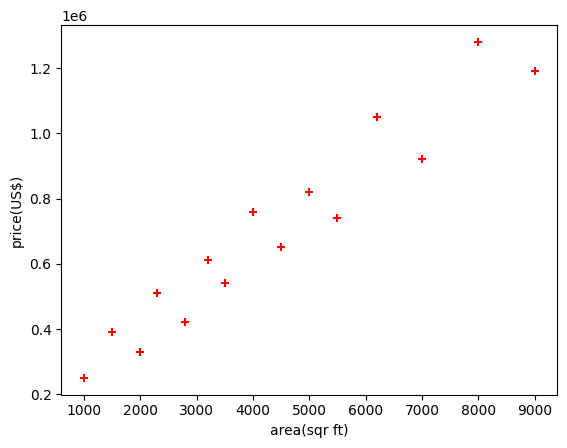

In [11]:
%matplotlib inline
plt.xlabel('area(sqr ft)')
plt.ylabel('price(US$)')
plt.scatter(df.area, df.prices, color='red', marker='+')           

via Scipy - investigate the relationship
(statistical information about the relationship)

In [12]:
from scipy import stats

X = df['area']
y = df['prices']

slope, intercept, r, p, std_err = stats.linregress(X, y)

print('Slope:', slope)
print('Intercept:', intercept)
print('Correlation:', r)
print('P-value:', p)
print('Standard error:', std_err)
print('R-squared:', r**2)

Slope: 124.3378166515389
Intercept: 154391.5339549468
Correlation: 0.9607870107412577
P-value: 1.2873796410795289e-08
Standard error: 9.952555855938934
R-squared: 0.9231116800091217


In [13]:
#prediction
predict_price_scipy = intercept + slope*3300
print(predict_price_scipy)

564706.3289050251


Scikti-learn

In [14]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# 1. Define predictors and target
X = df[['area']]
y = df['prices']

In [15]:
# 2. Create a regresssion model
model = LinearRegression()

#3. Fit model
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [16]:
# 4. Predict model
new_area = pd.DataFrame({'area': [3300]})

In [17]:
5. #Ask model to predict
prediction = model.predict(new_area)
print(prediction)

[564706.32890503]


In [18]:
# Prediction
def predict_price(area):
    return intercept + slope * area

predicted_price = predict_price(5000)
print(predicted_price)

776080.6172126413


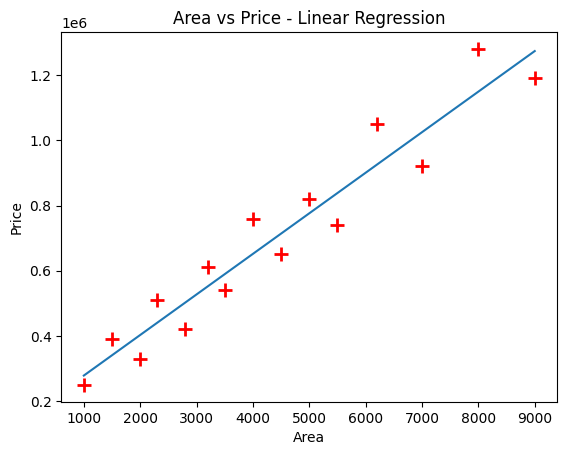

In [19]:
import matplotlib.pyplot as plt

# Original data
plt.scatter(df['area'], df['prices'], color='red', marker='+', s = 100, linewidths=2)

# Regression line
plt.plot(df['area'], model.predict(df[['area']]))
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price - Linear Regression')
plt.show()




## Exercise from scikit-learn

In [20]:
# Linear Model
from sklearn import linear_model
reg = linear_model.LinearRegression()
reg.fit([[0, 0], [1, 1], [2, 2]], [0, 1, 2])
print('Coefficients:', reg.coef_)
print(f'Intercept: {reg.intercept_: .2f}')

Coefficients: [0.5 0.5]
Intercept:  0.00


In [21]:
# Ridge Model
from sklearn import linear_model
reg = linear_model.Ridge(alpha=.5)
reg.fit([[0, 0], [0, 0], [1, 1]], [0, .1, 1])
print('Coefficients:', reg.coef_)
print(f'Intercept: {reg.intercept_: .2f}')

Coefficients: [0.34545455 0.34545455]
Intercept:  0.14


Ridge is linear regression with regularisation. It penalizes large coefficients and can be useful when predictors overlap strongly or ordinary regression becomes unstable.

## Diabates Example

In [22]:
# Load the diabetes dataset (one feature only)
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
X, y = load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)

In [23]:
#Create a linear regression model and fit it on the training data. 
from sklearn.linear_model import LinearRegression
regressor = LinearRegression().fit(X_train, y_train)

In [24]:
#Model evaluation using MSE (mean square error + coeffcient of determination)
from sklearn.metrics import mean_squared_error, r2_score

y_pred = regressor.predict(X_test)

print(f'Mean squared error: {mean_squared_error(y_test, y_pred):.2f}')
print(f'Coefficient of determination: {r2_score(y_test, y_pred):.2f}')

Mean squared error: 2548.07
Coefficient of determination: 0.47


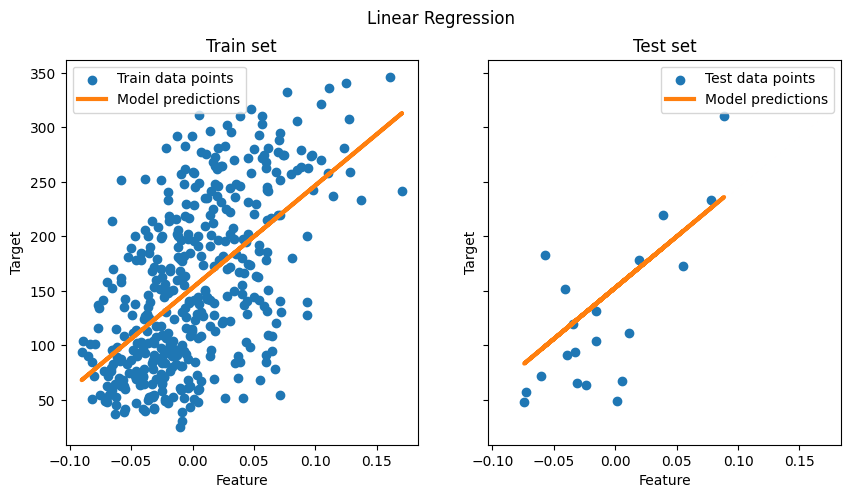

In [25]:
# Plotting the results on the train and test data.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label='Train data points')
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color='tab:orange',
    label='Model predictions',
)
ax[0].set(xlabel='Feature', ylabel='Target', title='Train set')
ax[0].legend()

ax[1].scatter(X_test, y_test, label='Test data points')
ax[1].plot(X_test, y_pred, linewidth=3, color='tab:orange', label='Model predictions')
ax[1].set(xlabel='Feature', ylabel='Target', title='Test set')
ax[1].legend()

fig.suptitle('Linear Regression')

plt.show()

OLS on this single-feature subset learns a linear function that minimises the mean squared error on the training data. We can see how well (or poorly) it generalizes by looking at the R^2 score and mean squared error on the test set. In higher dimensions, pure OLS often overfits, especially if the data is noisy. Regularization techniques (like Ridge or Lasso) can help reduce that.

# Ordinary Least Squares vs Ridge Regression

Ridge regression addresses some of the problems of Ordinary Least Squares by imposing a penalty on the size of the coefficients. The ridge coefficients minimize a penalized residual sum of squares. The complexity parameter alpha controls the amount of shrinkage: the larger the value of the greater the amount of shrinkage and thus the coefficients become more robust to collinearity.

In [26]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

In [27]:
#data preparation
X_train = np.c_[0.5, 1].T
y_train = [0.5, 1]
X_test = np.c_[0, 2].T

np.random.seed(0)

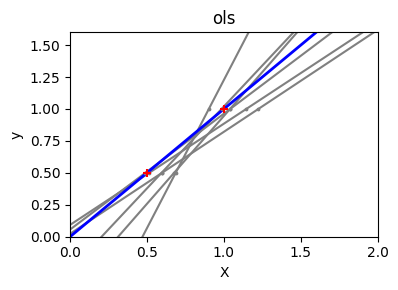

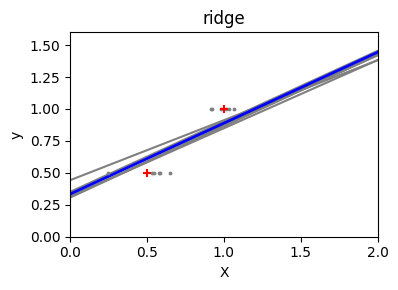

In [28]:
# Create 2 models; alpha=0.1 controls how much regularisation Ridge applies
classifiers = dict(
    ols=linear_model.LinearRegression(), ridge=linear_model.Ridge(alpha=0.1)
)

# Looping through 2 models; creating graphs for each model 
for name, clf in classifiers.items():
    fig, ax = plt.subplots(figsize=(4, 3))

    for _ in range(6):
        this_X = 0.1 * np.random.normal(size=(2, 1)) + X_train
        clf.fit(this_X, y_train)

        ax.plot(X_test, clf.predict(X_test), color='gray')
        ax.scatter(this_X, y_train, s=3, c='gray', marker='o', zorder=10)

    clf.fit(X_train, y_train)
    ax.plot(X_test, clf.predict(X_test), linewidth=2, color='blue')
    ax.scatter(X_train, y_train, s=30, c='red', marker='+', zorder=10)

    ax.set_title(name)
    ax.set_xlim(0, 2)
    ax.set_ylim((0, 1.6))
    ax.set_xlabel('X')
    ax.set_ylabel('y')

    fig.tight_layout()

plt.show()

OLS lines varied drastically each time noise was added, reflecting its high variance when data is sparse or noisy. By contrast, Ridge regression introduces a regularization term that shrinks the coefficients, stabilizing predictions.
Techniques like Ridge or Lasso (which applies an L1 penalty) are both common ways to improve generalization and reduce overfitting. A well-tuned Ridge or Lasso often outperforms pure OLS when features are correlated, data is noisy, or sample size is small.

## 2. Linear versus Mulitple Linear Regression

* Muliple predictors are available to predict the target.
* Model estimates coeeficients for each predictor. 
* Predictors can overalapp, creating potential mulitcollinearity problem

Predicted CO₂ = Intercept + (b₁ × Engine Size) + (b₂ × Cylinders) + (b₃ × Fuel Consumption)

In [29]:
#Import
import pandas as pd
from sklearn import linear_model
import matplotlib.pyplot as plt

In [31]:
#File loading
df = pd.read_csv("data/cars.csv")

**Modelling Linear Regression:** 

* Select X and y
* train/test split
* fit on training data
* predict test data
* evaluate performance

In [ ]:
# Model Training
X = df[['Weight', 'Volume']]
y = df['CO2']

regr = linear_model.LinearRegression()
regr.fit(X, y) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
#Predict the CO2 emission of a car where the weight is 2300kg, and the volume is 1300cm3:

new_car = pd.DataFrame({'Weight': [2300], 'Volume': [1300]})

predictedCO2 = regr.predict(new_car)

print('CO2 prediction:', predictedCO2)

CO2 prediction: [107.2087328]


## Coefficient

* The coefficient is a factor that describes the relationship with an unknown variable. 
* Each varibale gets its own coefficient. We can ask for the coefficient value of weight against CO2, and for volume against CO2. 

The answer will tells us what would happen if we increase, or decrease, one of the independent values.

In [ ]:
print(regr.coef_)

[0.00755095 0.00780526]


In [ ]:
print(regr.intercept_)

79.69471929115937


The result array represents the coefficient values of weight and volume.

* Weight: 0.00755095
* Volume: 0.00780526

**Regression equation: Predicted CO₂ = 79.69 + (0.00755095 × Weights) + (0.00780526 × Volume)**

These values indicate that: 
* if the weight increase by 1kg, the CO2 emission increases by 0.00755095g.
* if the engine size (Volume) increases by 1 cm3, the CO2 emission increases by 0.00780526 g.

Based on the earlier prediction if a car with a 1300cm3 engine weighs 2300kg, the CO2 emission will be approximately 107g.

What if we increase the weight with 1000kg (from 2300 to 3300) what will be the CO2 emission?

Ans: 107.2087328 + (1000 * 0.00755095) = 114.75968

Predicted CO₂ = 79.69 + (0.00755095 × 3300) + (0.00780526 × 1300) = 114.754973

## Additional Exercise
Define X/y → create LinearRegression() → .fit() → inspect coefficients → .predict()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [ ]:
data = {

    'age': [2, 5, 3, 8, 6, 1, 10, 4, 7, 3, 9, 5],
    'km_driven': [25000, 70000, 42000, 120000, 85000, 15000, 145000, 55000, 100000, 35000, 130000, 65000
    ],
    'engine': [1500, 1200, 1600, 1200, 1400, 2000, 1200, 1800, 1300, 1600, 1500, 1400
    ],
    'selling_price': [18500, 10500, 16000, 5500, 8500, 26000, 4000, 17000, 7000, 17500, 6000, 11500
    ]

}

df = pd.DataFrame(data)
df

,age,km_driven,engine,selling_price
0,2,25000,1500,18500
1,5,70000,1200,10500
2,3,42000,1600,16000
3,8,120000,1200,5500
4,6,85000,1400,8500
5,1,15000,2000,26000
6,10,145000,1200,4000
7,4,55000,1800,17000
8,7,100000,1300,7000
9,3,35000,1600,17500


In [ ]:
# 1. Define predictors and target
X = df[['age','km_driven','engine']]
y = df['selling_price']

In [ ]:
#check the predictors
X.head()

,age,km_driven,engine
0,2,25000,1500
1,5,70000,1200
2,3,42000,1600
3,8,120000,1200
4,6,85000,1400


In [ ]:
from sklearn.linear_model import LinearRegression

# 2. Create a regresssion model
model = LinearRegression()

# 3. Fit model
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# Inspect coefficients
pd.DataFrame({
    'Coefficient':model.coef_},
             index=X.columns)

,Coefficient
age,-2852.992795
km_driven,0.081650
engine,9.746419


In [ ]:
pd.DataFrame({'Intercept': [model.intercept_]})

,Intercept
0,6900.249933


Interpretation: 

Holding the other predictors constant, 
* One additional year of age is associated with approximately €2853 lower predicted selling price.
* One additional 1000km driven is associated with approximately €80 higher predicted selling price.
* One additional cc of engine is associated with approximately €10 higher predicted selling price.

Observation: higher mileage lead to slighly higher price?

In [ ]:
# predict new vehicle
new_car = pd.DataFrame({
    'age': [4],
    'km_driven': [5000],
    'engine': [1500],
})

predicted_price = model.predict(new_car)
print('Predicted selling price:', predicted_price[0])

Predicted selling price: 10516.159468793248


In [ ]:
# predicted model
selling_price_predicted = model.predict(X)


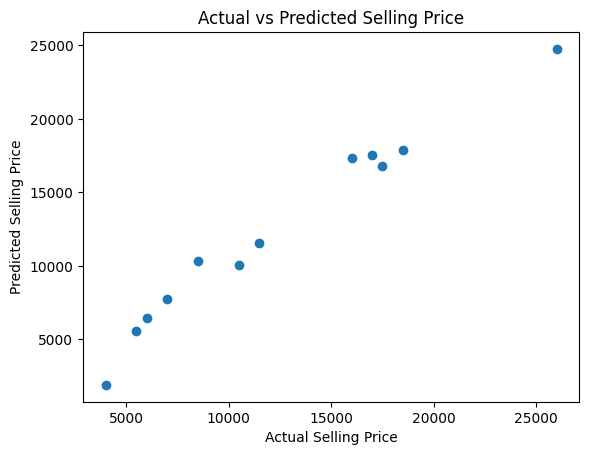

In [ ]:
# Actual price vs predicted price
plt.scatter(y, selling_price_predicted)

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.show()

## Evalaution with Train Test split

In [ ]:
#Train Test split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
# 1. Define X and y

X = df[["age", "km_driven", "engine"]]
y = df["selling_price"]

In [ ]:
# 2. Split the existing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# 3. Create a NEW model
model = LinearRegression()

In [ ]:
# 4. Train it ONLY on training data
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# 5. Predict the unseen test data
y_pred = model.predict(X_test)

## 3. Polynomial Regression

Simple linear regression assumes the relationship can be represented by a straight line: **Y = b₀ + b₁X**

Multiple linear regression: **Y = b₀ + b₁X + b₂X + b₃X**

Polynomial regression allows the line to curve by adding powers of X predictors to capture non-linearity:

Degree 2:**Y = b₀ + b₁X + b₂X²**

Degree 3: **Y = b₀ + b₁X + b₂X² + b₃X³**

- Degree 1 → straight line
- Degree 2 → one bend
- Degree 3 → more flexibility
- Degree 4+ → increasingly flexible

Example: 18 cars passing a certain tollboth at different time of the day (x) with different speed (y)

In [ ]:
#Import
import numpy
import matplotlib.pyplot as plt

In [ ]:
#Create the arrays that represent the values of the x and y axis
x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

In [ ]:
#NumPy has a method that lets us make a polynomial model (3 degree) to X and Y and creates a usable prediction function from it.
mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

print(mymodel)

          3         2
-0.03032 x + 1.343 x - 15.54 x + 113.8


In [ ]:
mymodel(5)

np.float64(65.8697052931668)

In [ ]:
#specify how the line will display, we start at position 1, and end at position 22
myline = numpy.linspace(1, 22, 100)

In [ ]:
mymodel(myline)

array([99.54274393, 96.85340483, 94.27503108, 91.80588631, 89.44423412,
       87.18833813, 85.03646197, 82.98686925, 81.03782359, 79.18758861,
       77.43442791, 75.77660513, 74.21238388, 72.74002778, 71.35780044,
       70.06396549, 68.85678653, 67.7345272 , 66.69545109, 65.73782185,
       64.85990307, 64.05995838, 63.3362514 , 62.68704574, 62.11060503,
       61.60519287, 61.1690729 , 60.80050871, 60.49776394, 60.2591022 ,
       60.08278711, 59.96708229, 59.91025135, 59.91055791, 59.96626559,
       60.07563801, 60.23693878, 60.44843152, 60.70837986, 61.0150474 ,
       61.36669776, 61.76159458, 62.19800145, 62.674182  , 63.18839984,
       63.7389186 , 64.3240019 , 64.94191334, 65.59091655, 66.26927514,
       66.97525274, 67.70711296, 68.46311941, 69.24153572, 70.04062551,
       70.85865239, 71.69387997, 72.54457188, 73.40899174, 74.28540316,
       75.17206976, 76.06725515, 76.96922297, 77.87623681, 78.78656031,
       79.69845707, 80.61019072, 81.52002487, 82.42622315, 83.32

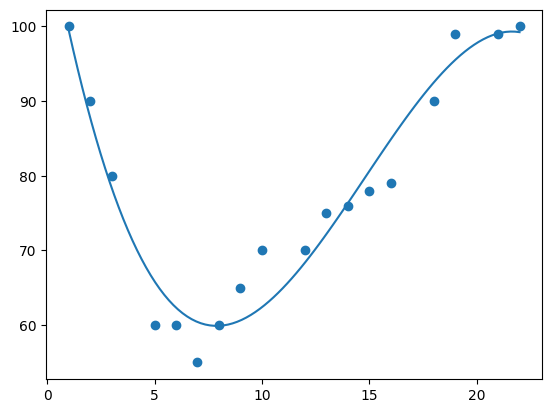

In [ ]:
plt.scatter(x, y)
plt.plot(myline, mymodel(myline))
plt.show()

It is important to know how well the relationship between the values of the x- and y-axis is, if there are no relationship the polynomial regression can not be used to predict anything.

The relationship is measured with a value called the r-squared.

The r-squared value ranges from 0 to 1, where 0 means no relationship, and 1 means 100% related

In [ ]:
import numpy
from sklearn.metrics import r2_score

x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

print('R²:', r2_score(y, mymodel(x)))

R²: 0.9432150416451025


The cubic polynomial explains apporaximately 94.3% of the variation in Y in these observed data.

## Predict Future Values

Let us try to predict the speed of a car that passes the tollbooth at around 17 P.M

In [ ]:
import numpy
from sklearn.metrics import r2_score

x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]
y = [100,90,80,60,60,55,60,65,70,70,75,76,78,79,90,99,99,100]

mymodel = numpy.poly1d(numpy.polyfit(x, y, 3))

speed = mymodel(17)
print('Speed:', speed)

Speed: 88.87331269697975


## Addtional Exercises (sales vs advertising spent) 

Plot → identify curvature → fit polynomial → create smooth curve → calculate R² → make a new prediction.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Advertising spend (£000)
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# Sales (£000)
y = np.array([12, 15, 21, 30, 42, 57, 75, 96, 120, 147])

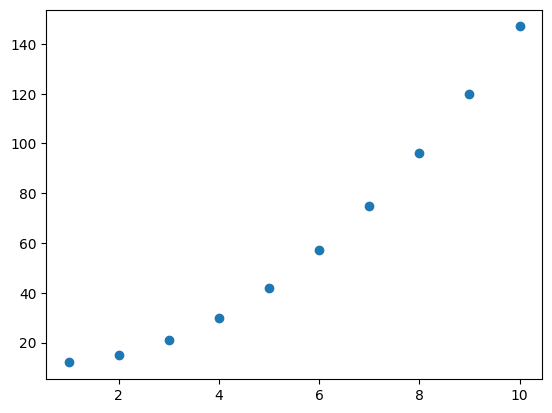

In [ ]:
plt.scatter(x, y)
plt.show()

In [ ]:
#Fitting a degree-2 polyniomial

newmodel = numpy.poly1d(numpy.polyfit(x, y, 2))
print(newmodel)

     2
1.5 x - 1.5 x + 12


In [ ]:
print('R²:', r2_score(y, newmodel(x)))

R²: 1.0


In [ ]:
newline = numpy.linspace(1, 10, 100)

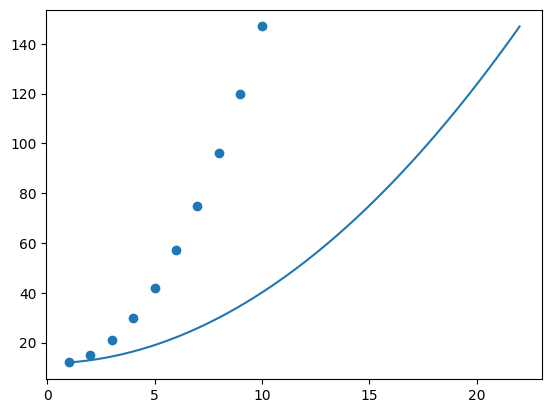

In [ ]:
plt.scatter(x, y)
plt.plot(myline, newmodel(newline))
plt.show()